# Integrating bayesflow-trained likelihoods into HSSM (NLE via ONNX)

This notebook covers the bayesflow version of the ONNX-based NLE integration workflow in HSSM. Once you've trained a [bayesflow](https://github.com/bayesflow-org/bayesflow) `ContinuousApproximator` (NLE) or `RatioApproximator` (NRE), you can export it to a single ONNX file and hand the path to HSSM. From HSSM's side, the file is consumed identically to a LAN export or an sbi export — same `loglik="file.onnx"` gesture, no library-specific glue.

Two paths into HSSM exist, side by side:

| Path | Source | Mechanism | When to use |
|---|---|---|---|
| `loglik="file.onnx"` | sbi or bayesflow | ONNX file, framework-agnostic | Portability, sharing trained surrogates |
| `loglik=<jax_callable>` | bayesflow (this tutorial's sibling) | In-memory JAX callable | Fast iteration during model development |

See [`bayesflow_lre_integration.ipynb`](./bayesflow_lre_integration.ipynb) for the JAX-callable path. This notebook covers the ONNX path.

## Part 1 — Setup

**Critical**: `KERAS_BACKEND=torch` must be set *before* importing `keras` or `bayesflow`. `torch.onnx.export` cannot trace a JAX-backed Keras model. On Apple silicon also pin `KERAS_TORCH_DEVICE=cpu` to avoid the orthogonal initializer's missing MPS op.

**Note on the two ONNX-related setup lines below** (`jax_enable_x64` and the `jaxonnxruntime` strict-mode relax): these are the same workarounds that HSSM PR #964 plans to auto-handle inside `hssm.distribution_utils.onnx2jax`. Until that PR lands on `main`, this tutorial sets them explicitly so it runs standalone. Once #964 merges, both lines can be deleted — HSSM will take care of them on import.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
os.environ["KERAS_TORCH_DEVICE"] = "cpu"

import jax

# x64 BEFORE other JAX-touching imports; ONNX graphs from torch.onnx.export
# carry int64 shape/index tensors that get silently truncated under JAX's
# default int32 mode, producing wrong log-prob values inside HSSM.
jax.config.update("jax_enable_x64", True)

# Relax jaxonnxruntime's default strict mode on Reshape shape arguments —
# torch.onnx.export emits them as Constant nodes, not initializers, which the
# strict default rejects. Safe because the shapes are genuinely constant.
# HSSM PR #964 sets this automatically inside hssm.distribution_utils.onnx2jax;
# until that PR lands on main, we set it here.
from jaxonnxruntime import config as _jaxonnx_config

_jaxonnx_config.update("jaxort_only_allow_initializers_as_static_args", False)

import tempfile  # noqa: F401 — available for the Part 4 override example
from pathlib import Path

import arviz as az
import bayesflow as bf
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bayesflow.datasets import OfflineDataset
from bayesflow.networks.inference.coupling.transforms import AffineTransform
from lanfactory.onnx import transform_bayesflow_to_onnx
from ssms.basic_simulators.simulator import simulator

import hssm

print("keras backend:", keras.backend.backend())
print("bayesflow:    ", bf.__version__)
print("hssm:         ", hssm.__version__)

INFO:bayesflow:Using backend 'torch'


When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


INFO:2026-06-30 02:19:50,875:jax._src.xla_bridge:925: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'


INFO:2026-06-30 02:19:50,876:jax._src.xla_bridge:925: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/afengler/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/afengler/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)


mlflow not available
mlflow not available
keras backend: torch
bayesflow:     2.0.12
hssm:          0.3.0


## Part 2 — Simulate observed DDM data

We use [`ssm-simulators`](https://github.com/AlexanderFengler/ssm-simulators) for ground-truth DDM samples at a known parameter vector. HSSM consumes a `DataFrame` with `rt` and `response` columns.

In [2]:
DDM_PARAM_NAMES = ["v", "a", "z", "t"]
DDM_PARAM_LOW = np.array([-2.0, 0.6, 0.3, 0.1], dtype=np.float32)
DDM_PARAM_HIGH = np.array([2.0, 1.8, 0.7, 0.5], dtype=np.float32)
TRUE_THETA = np.array([0.5, 1.2, 0.5, 0.25], dtype=np.float32)
N_OBS = 500

out = simulator(theta=TRUE_THETA[None, :], model="ddm", n_samples=N_OBS)
obs_data = pd.DataFrame(
    {
        "rt": out["rts"].squeeze().astype(np.float32),
        "response": out["choices"].squeeze().astype(np.float32),
    }
)
obs_data.head()

,rt,response
0,0.982721,1.0
1,0.417203,1.0
2,1.533354,1.0
3,0.721513,1.0
4,1.038754,1.0


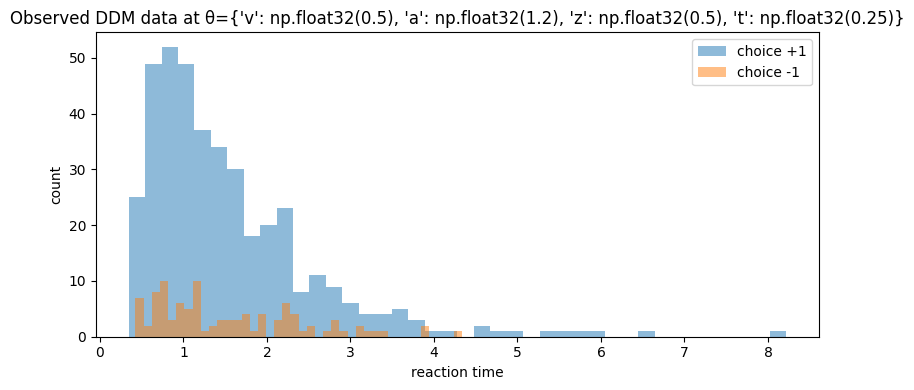

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for choice, label in [(1.0, "choice +1"), (-1.0, "choice -1")]:
    rts = obs_data.loc[obs_data["response"] == choice, "rt"]
    ax.hist(rts, bins=40, alpha=0.5, label=label)
ax.set_xlabel("reaction time")
ax.set_ylabel("count")
ax.legend()
ax.set_title(f"Observed DDM data at θ={dict(zip(DDM_PARAM_NAMES, TRUE_THETA))}")
plt.tight_layout()

## Part 3 — Train a bayesflow CouplingFlow NLE on DDM simulations

The CouplingFlow setup below is the v1 ONNX-friendly configuration documented in [LANfactory's `exporting_bayesflow_models.md`](https://github.com/lnccbrown/LANFactory/blob/main/docs/exporting_bayesflow_models.md). Three opinionated choices that aren't bayesflow's defaults:

- `permutation=None` — `FixedPermutation` uses `keras.ops.take`, which exports as `aten::ravel`, unsupported in ONNX opset 17/20.
- `transform=AffineTransform(clamp=False)` (explicit instance) — default `clamp=True` emits `aten::asinh`. Also, `bf.networks.CouplingFlow(..., transform_kwargs={"clamp": False})` silently drops the kwarg (upstream bug); pass an instance.
- `activation="silu"` — default `"hard_silu"` exports as a single fused `HardSwish` op that jaxonnxruntime can't run. Real SiLU decomposes to `Sigmoid` + `Mul`.

In [4]:
keras.utils.set_random_seed(0)
rng = np.random.default_rng(0)

N_TRAIN = 20_000
theta_train = rng.uniform(
    DDM_PARAM_LOW, DDM_PARAM_HIGH, size=(N_TRAIN, len(DDM_PARAM_NAMES))
).astype(np.float32)

# One trial per (θ_i) — NLE convention: each row is (θ_i, x_i).
x_train = np.empty((N_TRAIN, 2), dtype=np.float32)
for i, th in enumerate(theta_train):
    out = simulator(theta=th[None, :], model="ddm", n_samples=1)
    x_train[i, 0] = out["rts"].squeeze()
    x_train[i, 1] = out["choices"].squeeze()

print("theta_train:", theta_train.shape, "  x_train:", x_train.shape)

theta_train: (20000, 4)   x_train: (20000, 2)


In [5]:
approximator = bf.ContinuousApproximator(
    inference_network=bf.networks.CouplingFlow(
        depth=6,
        subnet_kwargs={"widths": (64, 64), "activation": "silu", "dropout": None},
        permutation=None,
        use_actnorm=False,
        transform=AffineTransform(clamp=False),
    ),
    standardize="inference_variables",  # standardize x (rt, choice)
)
approximator.build(
    {
        "inference_variables": (None, 2),
        "inference_conditions": (None, len(DDM_PARAM_NAMES)),
    }
)
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4))

dataset = OfflineDataset(
    data={
        "inference_variables": x_train,
        "inference_conditions": theta_train,
    },
    batch_size=256,
    adapter=None,  # MUST be identity for ONNX export; we use only the in-network Standardize layer
)
history = approximator.fit(dataset=dataset, epochs=50, verbose=1)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


Epoch 1/50


 1/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.8379

 7/79 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7895 

12/79 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5740

...

57/79 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: -1.4893

64/79 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: -1.4637

71/79 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: -1.5554

78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: -1.3591

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: -1.3431


## Part 4 — Export the trained approximator to ONNX

One call. The exporter raises clearly if any v1 constraint is violated (wrong `KERAS_BACKEND`, non-identity adapter, missing `inference_network`).

**Where to write the file.** The cell below sets `ARTIFACT_DIR` to `~/bayesflow_onnx_tutorial/` — outside the HSSM repo, so re-running the notebook doesn't leave artifacts in your working tree. Change it to any path you want to keep the trained ONNX around for downstream work; set it to `tempfile.mkdtemp()` for an ephemeral demo run.

In [6]:
# User-configurable: where the .onnx file lands. Default is outside the HSSM
# repo so notebook re-runs don't pollute the working tree.
# Override examples:
#   ARTIFACT_DIR = Path("/path/to/my/project/onnx")          # keep nearby
#   ARTIFACT_DIR = Path(tempfile.mkdtemp())                  # ephemeral
ARTIFACT_DIR = Path.home() / "bayesflow_onnx_tutorial"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
onnx_path = ARTIFACT_DIR / "ddm_nle.onnx"

transform_bayesflow_to_onnx(
    approximator,
    str(onnx_path),
    mode="nle",
    example_theta_dim=len(DDM_PARAM_NAMES),
    example_x_dim=2,
)
print(f"wrote {onnx_path}  ({onnx_path.stat().st_size:,} bytes)")

/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/keras/src/backend/common/variables.py:634: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  d = int(d)
/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/keras/src/backend/torch/numpy.py:1898: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if dim % indices_or_sections != 0:
/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/keras/src/backend/torch/numpy.py:1912: TracerWarni

wrote /Users/afengler/bayesflow_onnx_tutorial/ddm_nle.onnx  (298,339 bytes)


## Part 5 — Hand the ONNX to HSSM

The user gesture is identical to the sbi path and the LAN-MLP path. HSSM detects the `.onnx` extension, loads it via `jaxonnxruntime`, vmaps over trials, and wires it into a PyMC `Distribution`.

In [7]:
model_nle = hssm.HSSM(
    data=obs_data,
    model="ddm",
    loglik_kind="approx_differentiable",
    loglik=str(onnx_path),
    p_outlier=0,
)
model_nle

INFO:jaxonnxruntime.call_onnx:Start tracing the jax_func model to get some static info


INFO:/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/pytensor/link/c/lazylinker_c.py:Compiling new CVM


INFO:/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/pytensor/link/c/lazylinker_c.py:New version 0.31


Model initialized successfully.


INFO:hssm:Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 500

Parameters:

v:
    Prior: Uniform(lower: -3.0, upper: 3.0)
    Explicit bounds: (-3.0, 3.0)

a:
    Prior: Uniform(lower: 0.3, upper: 2.5)
    Explicit bounds: (0.3, 2.5)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, 2.0)

In [8]:
idata_nle = model_nle.sample(
    sampler="numpyro",
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    mp_ctx="spawn",
)

Using default initvals. 



INFO:hssm:Using default initvals. 



/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/2000 [00:00<?, ?it/s]

warmup:   0%|          | 1/2000 [00:00<26:04,  1.28it/s, 1 steps of size 1.95e+00. acc. prob=0.00]

...

 80%|███████▉  | 1591/2000 [00:01<00:00, 1051.61it/s]

 85%|████████▍ | 1697/2000 [00:01<00:00, 1052.09it/s]

 90%|█████████ | 1804/2000 [00:01<00:00, 1055.01it/s]

 96%|█████████▌| 1910/2000 [00:01<00:00, 1053.08it/s]

100%|██████████| 2000/2000 [00:02<00:00, 968.06it/s] 

In [9]:
summary_nle = az.summary(idata_nle, var_names=DDM_PARAM_NAMES)
summary_nle

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v,0.249,0.043,0.163,0.321,0.001,0.001,1153.0,1111.0,1.0
a,1.371,0.033,1.309,1.432,0.001,0.001,863.0,928.0,1.0
z,0.639,0.023,0.596,0.681,0.001,0.001,932.0,926.0,1.0
t,0.318,0.016,0.292,0.344,0.001,0.000,783.0,800.0,1.0


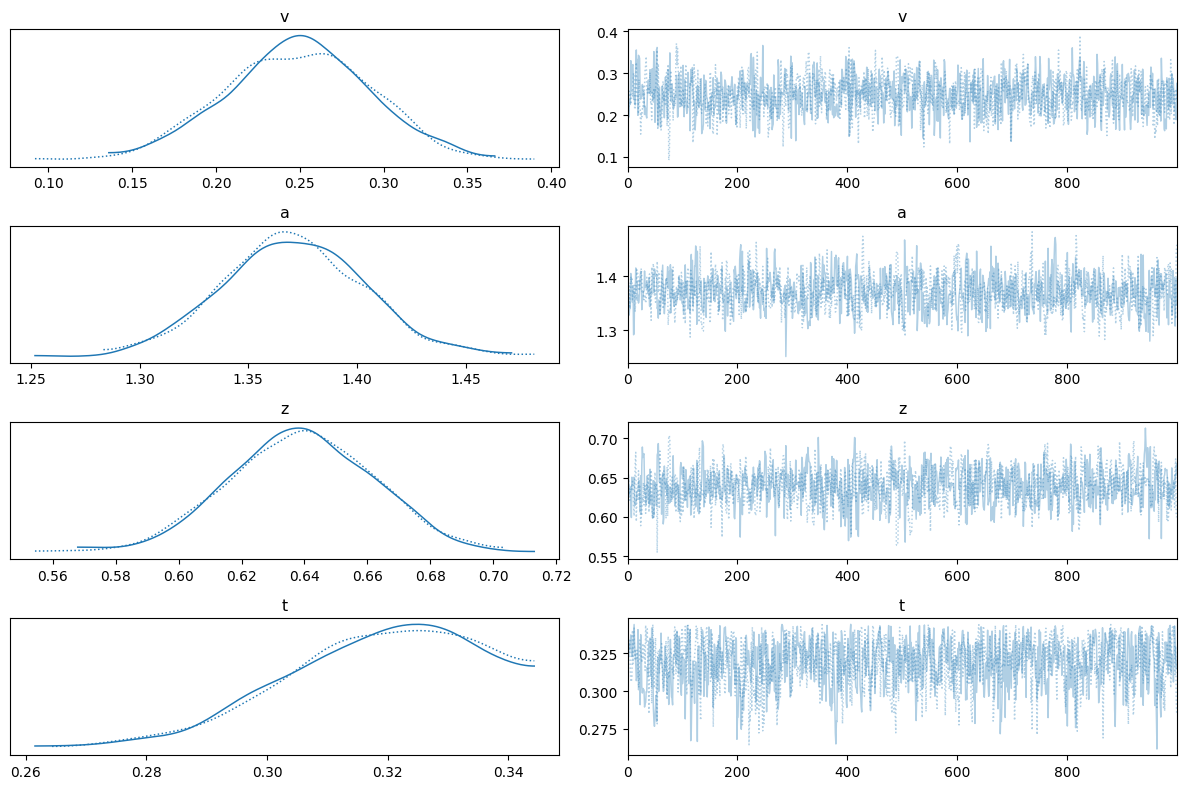

In [10]:
az.plot_trace(idata_nle, var_names=DDM_PARAM_NAMES)
plt.tight_layout()

## Part 6 — Ground-truth posterior via HSSM's analytical DDM

DDM has a closed-form likelihood (Navarro & Fuss). Comparing the bayesflow-NLE posterior to this gives a fairness check: any drift comes from the neural approximation, not from the inference machinery.

In [11]:
model_analytical = hssm.HSSM(
    data=obs_data,
    model="ddm",
    p_outlier=0,
    # default loglik_kind here is the analytical Navarro & Fuss path
)
idata_analytical = model_analytical.sample(
    sampler="numpyro",
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    mp_ctx="spawn",
)
summary_analytical = az.summary(idata_analytical, var_names=DDM_PARAM_NAMES)
summary_analytical

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Using default initvals. 



INFO:hssm:Using default initvals. 



/Users/afengler/Projects/proj_hssmspine/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


...


INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics


  0%|          | 0/2000 [00:00<?, ?it/s]

 49%|████▉     | 981/2000 [00:00<00:00, 9806.60it/s]

100%|██████████| 2000/2000 [00:00<00:00, 10342.12it/s]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v,0.557,0.051,0.461,0.653,0.002,0.001,1063.0,1026.0,1.01
a,1.243,0.029,1.193,1.300,0.001,0.001,1031.0,1203.0,1.00
z,0.500,0.017,0.470,0.532,0.001,0.000,986.0,1166.0,1.00
t,0.216,0.018,0.184,0.252,0.001,0.000,898.0,990.0,1.00


## Part 7 — Posterior comparison: bayesflow NLE vs analytical

Overlay marginals and mark the true values. If the bayesflow NLE was trained well, the two posterior densities should agree closely.

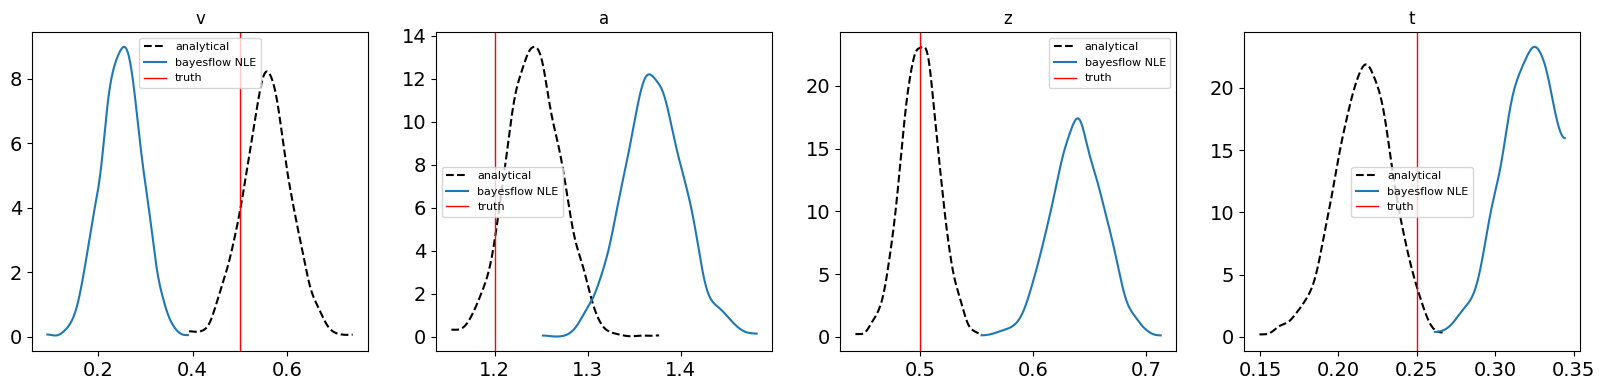

In [12]:
fig, axes = plt.subplots(1, len(DDM_PARAM_NAMES), figsize=(16, 4))
for ax, name, true_val in zip(axes, DDM_PARAM_NAMES, TRUE_THETA):
    az.plot_kde(
        idata_analytical.posterior[name].values.flatten(),
        plot_kwargs={"color": "black", "linestyle": "--", "label": "analytical"},
        ax=ax,
    )
    az.plot_kde(
        idata_nle.posterior[name].values.flatten(),
        plot_kwargs={"color": "tab:blue", "label": "bayesflow NLE"},
        ax=ax,
    )
    ax.axvline(true_val, color="red", lw=1, label="truth")
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()

## Summary

- **User gesture is the same as sbi or LAN-MLP**: `hssm.HSSM(loglik="file.onnx", loglik_kind="approx_differentiable")`. HSSM doesn't need to know which framework trained the surrogate.
- **The v1 constraints on the bayesflow side** (CouplingFlow with `permutation=None`, explicit `AffineTransform(clamp=False)`, `silu` not `hard_silu` activation, identity adapter, `KERAS_BACKEND=torch` at export time) are all enforced or documented by `lanfactory.onnx.transform_bayesflow_to_onnx`. The exporter raises clearly when a constraint is violated.
- **For an in-memory JAX-callable alternative** (no ONNX file, faster iteration during model development), see [`bayesflow_lre_integration.ipynb`](./bayesflow_lre_integration.ipynb).

Out of v1 scope (tracked as future work):

- MNLE-style discrete + continuous mixed observations
- Non-identity bayesflow Adapters (would require either baking the tensor-able subset into the ONNX graph, or shipping the adapter spec alongside the ONNX file)
- Transformer / attention summary networks (LayerNorm + dynamic-shape ops)
- FlowMatching / DiffusionModel / ConsistencyModel inference networks (`log_prob` requires ODE integration)